# Assignment 2 — Mean-Variance Analysis, VaR and Probability

This notebook is the **Python twin of `assignment_2.xlsx`**. Every number below is also computed
by a live formula in the workbook, so you can work in either tool and land on the same answer.

| Notebook | Workbook |
|---|---|
| §1 Setup | sheets `data`, `Monthly returns` |
| §2 Q1 — efficient portfolio with 5% volatility | `Q1_Q2_Portfolio` |
| §3 Q2 — true expected return of that portfolio | `Q1_Q2_Portfolio` |
| §4 Q3 — Value-at-Risk at 90% | `Q3_Q4_VaR` |
| §5 Q4 — Conditional Value-at-Risk at 90% | `Q3_Q4_VaR` |
| §6 Q5 — one manager, 12 of 15 | `Q5_Q7_Probability` |
| §7 Q6 — best of 100 managers, 14 of 15 | `Q5_Q7_Probability` |
| §8 Q7 — four-door Monty Hall | `Q5_Q7_Probability` |
| §9 Answer summary | `Answers` |

### The market

$$
\boldsymbol\mu=\begin{bmatrix}6\%\\2\%\\4\%\end{bmatrix},\qquad
\mathbf V=\begin{bmatrix}8.0&-2.0&4.0\\-2.0&2.0&-2.0\\4.0&-2.0&8.0\end{bmatrix}\times10^{-3},
\qquad r_f=1\%
$$

These are the **true** parameters. The `Monthly returns` sheet holds $N=60$ months simulated from
this market, and the **estimates** $\hat{\boldsymbol\mu},\hat{\mathbf V}$ built from them. Questions 1
and 2 turn on the difference between the two.

### A unit convention worth pinning down

Throughout — in the workbook and here — **returns are carried in percent** (`6` means 6%) while
**covariances are carried in decimals** (`0.008`). So volatility in percent is

$$\sigma(\mathbf x)=100\sqrt{\mathbf x'\mathbf V\mathbf x}$$

which is exactly what cell `B22` of the `data` sheet does. Mixing these up is the single most common
way to get an answer that is off by a factor of 100.

---
## 1. Setup — read the workbook

We read the same cells the Excel sheets read, so there is no chance of the two drifting apart.

In [1]:
import numpy as np
import pandas as pd
from math import comb

pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

XLSX = "assignment_2.xlsx"
ASSETS = ["Asset 1", "Asset 2", "Asset 3"]

# ---- true parameters (sheet 'data') ------------------------------------
mu_true = np.array([6.0, 2.0, 4.0])                  # annual, percent
V_true = np.array([[ 8.0, -2.0,  4.0],
                   [-2.0,  2.0, -2.0],
                   [ 4.0, -2.0,  8.0]]) * 1e-3       # annual, decimal
rf = 1.0                                             # percent

# ---- 60 simulated monthly returns (sheet 'Monthly returns', A2:C61) ----
returns = pd.read_excel(XLSX, sheet_name="Monthly returns",
                        usecols="A:C", nrows=60)
returns.columns = ASSETS

# ---- the estimates the workbook uses -----------------------------------
# mu_hat: 'Monthly returns'!F3:H3  = AVERAGE(monthly) * 12
mu_hat = returns.mean().to_numpy() * 12

# V_hat: 'Monthly returns'!F7:H9 - the sample covariance, annualised,
# converted from percent^2 to decimal^2, and stored rounded to 4 dp.
V_hat = np.round(returns.cov().to_numpy() * 12 / 1e4, 4)

print("Estimated annual mean return (%):")
print(pd.Series(mu_hat, index=ASSETS).to_string())
print("\nEstimated annual covariance matrix:")
print(pd.DataFrame(V_hat, index=ASSETS, columns=ASSETS).to_string(
    float_format=lambda v: f"{v: .4f}"))
print("\nEstimated annual volatility (%):")
print(pd.Series(100 * np.sqrt(np.diag(V_hat)), index=ASSETS).to_string())

Estimated annual mean return (%):
Asset 1   -0.5186
Asset 2    4.7057
Asset 3   -0.6986

Estimated annual covariance matrix:
         Asset 1  Asset 2  Asset 3
Asset 1   0.0056  -0.0020   0.0037
Asset 2  -0.0020   0.0022  -0.0022
Asset 3   0.0037  -0.0022   0.0074

Estimated annual volatility (%):
Asset 1   7.4833
Asset 2   4.6904
Asset 3   8.6023


Two things to notice before going further.

**Asset 2 looks nothing like it should.** Its true mean is 2%, the lowest of the three, but over
these particular 60 months it *estimated* at about 4.7% — the highest. Assets 1 and 3 both estimated
**negative**. That is not a bug in the simulation; it is what a 5-year sample does to a mean estimate.
The standard error of a mean return estimated from $N$ months is $\sigma/\sqrt{N}$, and with
$\sigma\approx 9\%$ and $N=60$ that is roughly 1.2 percentage points *per year* — comparable in size to
the differences between the assets we are trying to detect. Covariances, by contrast, are estimated
well: $\hat{\mathbf V}$ is close to $\mathbf V$.

**This is the whole point of questions 1 and 2.** Q1 optimises against $\hat{\boldsymbol\mu}$; Q2 asks
what that portfolio actually earns. The gap between them is the cost of estimation error.

In [2]:
comparison = pd.DataFrame({
    "true mu (%)": mu_true,
    "estimated mu (%)": mu_hat,
    "error": mu_hat - mu_true,
    "true vol (%)": 100 * np.sqrt(np.diag(V_true)),
    "estimated vol (%)": 100 * np.sqrt(np.diag(V_hat)),
}, index=ASSETS)
comparison

,true mu (%),estimated mu (%),error,true vol (%),estimated vol (%)
Asset 1,6.0000,-0.5186,-6.5186,8.9443,7.4833
Asset 2,2.0000,4.7057,2.7057,4.4721,4.6904
Asset 3,4.0000,-0.6986,-4.6986,8.9443,8.6023


---
## 2. Question 1 — efficient portfolio with 5% volatility

> *Compute an estimated efficient portfolio with 5% volatility. What is the estimated return?*

### The theory in one line

When a risk-free asset is available, the efficient frontier is a **straight line** out of $r_f$ through
the tangency portfolio. Every efficient portfolio is therefore the *same* mix of risky assets, just
levered up or down. Formally, solving

$$\max_{\mathbf x}\ \ \mathbf x'\boldsymbol\mu+(1-\mathbf 1'\mathbf x)r_f
\quad\text{s.t.}\quad \mathbf x'\mathbf V\mathbf x\le\sigma_{\text{target}}^2$$

gives

$$\boxed{\ \mathbf x = k\,\mathbf V^{-1}(\boldsymbol\mu-r_f\mathbf 1)\ }$$

for some scalar $k>0$. The direction $\mathbf z=\mathbf V^{-1}(\boldsymbol\mu-r_f\mathbf 1)$ is fixed;
$k$ only sets the scale. So we never need an optimiser:

1. compute $\mathbf z=\hat{\mathbf V}^{-1}(\hat{\boldsymbol\mu}-r_f\mathbf 1)$,
2. find its volatility $\sigma_z = 100\sqrt{\mathbf z'\hat{\mathbf V}\mathbf z}$,
3. set $k=\sigma_{\text{target}}/\sigma_z$ so the volatility comes out at exactly 5%,
4. put the remainder $x_0=1-\mathbf 1'\mathbf x$ in the risk-free asset.

A useful shortcut for step 2: since $\hat{\mathbf V}\mathbf z=\hat{\boldsymbol\mu}-r_f\mathbf 1$ by
construction, $\mathbf z'\hat{\mathbf V}\mathbf z=\mathbf z'(\hat{\boldsymbol\mu}-r_f\mathbf 1)$ —
a dot product rather than a second matrix multiply. The workbook uses the same trick.

### In Excel
`INDEX(MINVERSE(...))` for the inverse, then `SUMPRODUCT` for each row — see rows 26–40 of the
`Q1_Q2_Portfolio` sheet. The Solver block underneath solves the constrained problem directly and lands
in the same place.

In [3]:
def efficient_portfolio(mu, V, rf, target_vol):
    """Weights of the efficient portfolio with the requested volatility (in %).

    Returns (x_risky, x_riskfree). Volatility in % = 100*sqrt(x'Vx).
    """
    excess = mu - rf                      # percent
    z = np.linalg.solve(V, excess)        # V^-1 (mu - rf), never invert explicitly
    vol_z = 100 * np.sqrt(z @ excess)     # since V z = excess
    k = target_vol / vol_z
    x = k * z
    return x, 1.0 - x.sum()


def portfolio_return(x, x0, mu, rf):
    return x @ mu + x0 * rf


def portfolio_vol(x, V):
    return 100 * np.sqrt(x @ V @ x)


TARGET_VOL = 5.0
x, x0 = efficient_portfolio(mu_hat, V_hat, rf, TARGET_VOL)

print("Weights")
print(pd.Series(np.append(x, x0),
                index=ASSETS + ["Risk-free"]).to_string())
print(f"\nsum of weights            = {x.sum() + x0:.6f}   (must be 1)")
print(f"estimated volatility (%)  = {portfolio_vol(x, V_hat):.4f}   (must be 5)")

Q1 = portfolio_return(x, x0, mu_hat, rf)
print(f"\nQ1  estimated return (%)  = {Q1:.4f}   ->  submit {Q1:.2f}")

Weights
Asset 1      0.2143
Asset 2      1.3234
Asset 3      0.1534
Risk-free   -0.6911

sum of weights            = 1.000000   (must be 1)
estimated volatility (%)  = 5.0000   (must be 5)

Q1  estimated return (%)  = 5.3182   ->  submit 5.32


### Reading the portfolio

The weights are aggressive: about **132% in Asset 2**, funded by borrowing (`x0` is roughly $-69\%$).
The optimiser has done exactly what it was told — Asset 2 looked like the best performer in this
sample, so it piled in and levered up. Nothing about the procedure is wrong; the input was.

### Sanity check against a numerical optimiser

The closed form should agree with what Excel's Solver finds. Here is the same problem solved
numerically, starting from "everything in the risk-free asset" — the same starting point the Solver
block in the workbook uses.

In [4]:
from scipy.optimize import minimize

def solver_style(mu, V, rf, target_vol, x_start=(0.0, 0.0, 0.0)):
    """Mimic Excel Solver: maximise return subject to vol <= target, weights sum to 1."""
    neg_return = lambda w: -(w @ mu + (1 - w.sum()) * rf)
    constraints = [{"type": "ineq",
                    "fun": lambda w: target_vol - 100 * np.sqrt(w @ V @ w)}]
    res = minimize(neg_return, np.array(x_start), constraints=constraints,
                   method="SLSQP", options={"maxiter": 1000, "ftol": 1e-12})
    return res.x, 1 - res.x.sum()

x_solver, x0_solver = solver_style(mu_hat, V_hat, rf, TARGET_VOL)

print(pd.DataFrame({
    "closed form": np.append(x, x0),
    "Solver-style": np.append(x_solver, x0_solver),
}, index=ASSETS + ["Risk-free"]).to_string())

print(f"\nclosed form return  = {Q1:.6f}")
print(f"numerical  return  = {portfolio_return(x_solver, x0_solver, mu_hat, rf):.6f}")
assert np.allclose(x, x_solver, atol=1e-4), "the two methods disagree"
print("\nboth methods agree")

           closed form  Solver-style
Asset 1         0.2143        0.2143
Asset 2         1.3234        1.3234
Asset 3         0.1534        0.1534
Risk-free      -0.6911       -0.6911

closed form return  = 5.318191
numerical  return  = 5.318191

both methods agree


---
## 3. Question 2 — the true expected return of that portfolio

> *Compute the true expected return (realized return) of the portfolio from Problem 1.*

**Keep the weights, change the parameters.** The portfolio is fixed the moment we hand it to the
market; what changes is that its return is now priced with the *true* $\boldsymbol\mu=(6\%,2\%,4\%)$
rather than the sample estimate:

$$\mathbb E[r_p]=\mathbf x'\boldsymbol\mu+x_0 r_f$$

Do **not** re-optimise with the true parameters — that would answer a different question (what an
investor who already knew the truth would have earned).

In [5]:
Q2 = portfolio_return(x, x0, mu_true, rf)

print(pd.DataFrame({
    "weight": np.append(x, x0),
    "estimated mu (%)": np.append(mu_hat, rf),
    "true mu (%)": np.append(mu_true, rf),
    "contribution, estimated": np.append(x * mu_hat, x0 * rf),
    "contribution, true": np.append(x * mu_true, x0 * rf),
}, index=ASSETS + ["Risk-free"]).to_string())

print(f"\nQ1  estimated return (%)  = {Q1:.4f}")
print(f"Q2  true      return (%)  = {Q2:.4f}   ->  submit {Q2:.2f}")
print(f"    shortfall             = {Q1 - Q2:.4f} percentage points")
print(f"\nrisk actually taken (%)   = {portfolio_vol(x, V_true):.4f}"
      f"   (we were aiming at {TARGET_VOL})")

           weight  estimated mu (%)  true mu (%)  contribution, estimated  contribution, true
Asset 1    0.2143           -0.5186       6.0000                  -0.1111              1.2857
Asset 2    1.3234            4.7057       2.0000                   6.2276              2.6468
Asset 3    0.1534           -0.6986       4.0000                  -0.1072              0.6136
Risk-free -0.6911            1.0000       1.0000                  -0.6911             -0.6911

Q1  estimated return (%)  = 5.3182
Q2  true      return (%)  = 3.8550   ->  submit 3.86
    shortfall             = 1.4631 percentage points

risk actually taken (%)   = 4.8734   (we were aiming at 5.0)


### What this shows

The portfolio was *sold* as earning 5.32%; it actually earns **3.86%**. Roughly **1.46 percentage
points**, more than a quarter of the promised return, was never there — it was noise in
$\hat{\boldsymbol\mu}$ that the optimiser mistook for signal.

The realised volatility also comes out at 4.87% instead of 5.00%, but notice how much smaller that
miss is. Covariances are estimated from 60 observations of *second* moments and are fairly stable;
means are not. This asymmetry is why mean-variance optimisation is often described as an
**error-maximiser**: it systematically overweights whichever asset the sampling noise happened to
flatter. It is also the motivation for the fixes you meet later — shrinkage estimators, resampling,
Black–Litterman, or simply constraining weights.

---
## 4. Question 3 — Value-at-Risk at the 90% level

> *Column E of the `Value-at-Risk` sheet holds the monthly rate of loss on an equally weighted
> portfolio of the risky assets. Estimate the Value-at-Risk at the 90% probability level.*

The loss series is

$$L_t=-\frac{r_{1t}+r_{2t}+r_{3t}}{3}$$

— the sign flip is what makes it a *loss*, so a positive $L_t$ is a bad month.

**Definition.** VaR at level $p$ is the $p$-quantile of the loss distribution: the loss that gets
exceeded only $(1-p)$ of the time.

$$\mathbb P\left(L>\text{VaR}_p\right)=1-p$$

With no distributional assumption we estimate it **historically** — sort the 60 losses and read off
the point 90% of the way up. That is `PERCENTILE(losses, 0.9)` in Excel and `np.quantile(L, 0.9)` in
NumPy; both use the same linear interpolation between order statistics, so they agree to the last
decimal.

In [6]:
returns_var = pd.read_excel(XLSX, sheet_name="Value_at_risk", usecols="A:C", nrows=60)
returns_var.columns = ASSETS

# column E of the sheet: equally weighted loss
loss = -returns_var.mean(axis=1).to_numpy()

CONFIDENCE = 0.90
N = len(loss)

VaR = np.quantile(loss, CONFIDENCE)          # == Excel PERCENTILE(range, 0.9)

print(f"observations N            = {N}")
print(f"mean monthly loss (%)     = {loss.mean():.4f}")
print(f"worst month (%)           = {loss.max():.4f}")
print(f"months in the tail        = {int(round(N * (1 - CONFIDENCE)))}")
print(f"\nQ3  VaR at 90% (%)        = {VaR:.4f}   ->  submit {VaR:.2f}")
print(f"    months exceeding it   = {(loss > VaR).sum()}  ({(loss > VaR).mean():.1%})")

observations N            = 60
mean monthly loss (%)     = -0.0969
worst month (%)           = 2.3707
months in the tail        = 6

Q3  VaR at 90% (%)        = 1.3006   ->  submit 1.30
    months exceeding it   = 6  (10.0%)


Interpretation: **in the worst 10% of months this portfolio loses more than 1.30% of its value.**

One caution on the interpolation. With $N=60$ and $p=0.9$, Excel's `PERCENTILE` lands between the
54th and 55th sorted losses rather than on an actual observation, so the answer is a blend. Different
conventions (`lower`, `higher`, `nearest`) shift the third decimal. They do not change the answer to
two decimal places here, but it is worth knowing that "the" empirical quantile is not unique.

In [7]:
methods = ["linear", "lower", "higher", "nearest", "midpoint"]
print(pd.Series({m: np.quantile(loss, CONFIDENCE, method=m) for m in methods},
                name="VaR (%)").to_string())
print("\nExcel PERCENTILE / PERCENTILE.INC matches 'linear'.")

linear     1.3006
lower      1.2923
higher     1.3754
nearest    1.2923
midpoint   1.3338

Excel PERCENTILE / PERCENTILE.INC matches 'linear'.


---
## 5. Question 4 — Conditional Value-at-Risk at the 90% level

> *Use the same data to estimate the Conditional Value-at-Risk at the 90% probability level.*

VaR tells you the threshold you cross 10% of the time; it says **nothing about how bad things get
once you cross it**. Two portfolios can share a VaR and have completely different tails. CVaR —
also called expected shortfall — answers the follow-up question, "given that it *is* a bad month,
how bad on average?"

### The estimator the module prescribes

Sort the losses ascending, $L_{(1)}\le L_{(2)}\le\dots\le L_{(N)}$, and let $K_p$ be the index of
the order statistic the VaR sits at, $K_p=\lceil pN\rceil$. Then

$$\boxed{\ \widehat{\text{CVaR}}_p=\frac{\displaystyle\sum_{i=K_p}^{N}L_{(i)}}{(1-p)N}
=\frac{\text{sum of the largest }N-K_p+1\text{ losses}}{(1-p)N}\ }$$

**Mind the $+1$.** With $N=60$ and $p=0.9$:

| quantity | value |
|---|---|
| $K_p=\lceil 0.9\times 60\rceil$ | 54 |
| observations **summed**, $N-K_p+1$ | **7** |
| divisor, $(1-p)N$ | **6** |

So we add up **seven** losses and divide by **six**. That is deliberate and it is not an average —
the numerator reaches one observation further down the tail than the denominator counts. It looks
unnatural, and it is the single easiest place to lose the mark on this question, so it is worth
writing the two numbers out separately rather than reaching for `mean()`.

The effect is to include the VaR order statistic $L_{(54)}$ itself in the sum, which pushes the
estimate **above** the plain average of the 6 worst months. It is the conservative reading of the
tail. Both cells are computed below so you can see the size of the difference.

### In Excel
`SUMPRODUCT(LARGE(losses, ROW(INDIRECT("1:"&m))))` collects the largest $m$ losses; divide by
`(1-p)*N`. See rows 80–85 of the `Q3_Q4_VaR` sheet, where $K_p$, the count and the divisor each get
their own cell.

In [8]:
# --- the prescribed estimator, spelled out step by step -----------------
K_p = int(np.ceil(CONFIDENCE * N))          # index of the VaR order statistic
n_summed = N - K_p + 1                      # how many losses go into the SUM
divisor = (1 - CONFIDENCE) * N              # what we divide by - NOT the same number

loss_sorted = np.sort(loss)                 # ascending
tail_sum = loss_sorted[-n_summed:].sum()    # the largest (N - K_p + 1) losses

CVaR = tail_sum / divisor

print(f"K_p = ceil(p*N)            = {K_p}")
print(f"losses summed, N - K_p + 1 = {n_summed}")
print(f"divisor, (1-p)*N           = {divisor:.0f}      <- one fewer than we summed")
print()
print(pd.Series(loss_sorted[-n_summed:][::-1],
                index=[f"L({i})" for i in range(N, K_p - 1, -1)],
                name="largest losses summed (%)").to_string())
print(f"\nsum                        = {tail_sum:.4f}")
print(f"\nQ3  VaR  at 90% (%)        = {VaR:.4f}   ->  submit {VaR:.2f}")
print(f"Q4  CVaR at 90% (%)        = {CVaR:.4f}   ->  submit {CVaR:.2f}")

# --- how it differs from the naive tail average ------------------------
naive = loss_sorted[-6:].mean()
print(f"\nfor contrast, plain average of the 6 worst months = {naive:.4f}")
print(f"the prescribed estimator is higher by             = {CVaR - naive:.4f}")
print(f"    because it also picks up L({K_p}) = {loss_sorted[K_p-1]:.4f} "
      f"while still dividing by {divisor:.0f}")

assert np.isclose(CVaR, loss_sorted[K_p - 1:].sum() / divisor)

K_p = ceil(p*N)            = 54
losses summed, N - K_p + 1 = 7
divisor, (1-p)*N           = 6      <- one fewer than we summed

L(60)   2.3707
L(59)   2.1450
L(58)   1.9877
L(57)   1.9191
L(56)   1.8807
L(55)   1.3754
L(54)   1.2923

sum                        = 12.9709

Q3  VaR  at 90% (%)        = 1.3006   ->  submit 1.30
Q4  CVaR at 90% (%)        = 2.1618   ->  submit 2.16

for contrast, plain average of the 6 worst months = 1.9464
the prescribed estimator is higher by             = 0.2154
    because it also picks up L(54) = 1.2923 while still dividing by 6


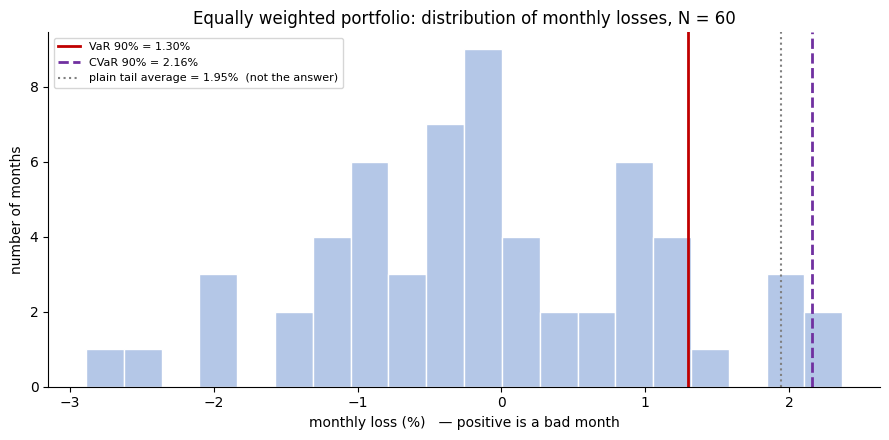

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(loss, bins=20, color="#B4C7E7", edgecolor="white")
ax.axvline(VaR, color="#C00000", lw=2, label=f"VaR 90% = {VaR:.2f}%")
ax.axvline(CVaR, color="#7030A0", lw=2, ls="--", label=f"CVaR 90% = {CVaR:.2f}%")
ax.axvline(naive, color="#808080", lw=1.5, ls=":",
           label=f"plain tail average = {naive:.2f}%  (not the answer)")
ax.set_xlabel("monthly loss (%)   — positive is a bad month")
ax.set_ylabel("number of months")
ax.set_title("Equally weighted portfolio: distribution of monthly losses, N = 60")
ax.legend(fontsize=8)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

The chart makes the distinction concrete: the red line is the point you pass 6 months out of 60,
the purple line is where the prescribed CVaR estimator lands. The grey dashed line is the plain
average of the 6 worst months — the "natural" answer, and the wrong one here. CVaR sits well to the
right of VaR either way: the tail is not thin.

---
## 6. Question 5 — one manager, 12 good years out of 15

> *A manager beat the market in 12 of 15 years. Under no skill ($p=0.5$, years independent), what is
> the probability of a record this good or better?*

This is a one-sided binomial test. Under the null the count of good years is

$$X\sim\text{Binomial}(n=15,\ p=0.5)$$

and we want the upper tail, "this good **or better**", so the inequality is $\ge 12$, not $>12$:

$$\mathbb P(X\ge 12)=\sum_{k=12}^{15}\binom{15}{k}\left(\tfrac12\right)^{15}
=\frac{\binom{15}{12}+\binom{15}{13}+\binom{15}{14}+\binom{15}{15}}{2^{15}}$$

In Excel there is no direct upper-tail function, so use the complement of the CDF:
`=1-BINOMDIST(11, 15, 0.5, TRUE)`. Note the **11**, not 12 — `BINOMDIST(...,TRUE)` returns
$\mathbb P(X\le k)$, and $\mathbb P(X\ge 12)=1-\mathbb P(X\le 11)$. Off-by-one here is the classic
way to lose the mark.

In [10]:
from scipy.stats import binom

n_years, p_null, k_obs = 15, 0.5, 12

Q5 = binom.sf(k_obs - 1, n_years, p_null)        # sf(k-1) = P(X >= k)

# the same thing counted out by hand
Q5_longhand = sum(comb(n_years, k) for k in range(k_obs, n_years + 1)) / 2 ** n_years

print(pd.DataFrame({
    "k": range(k_obs, n_years + 1),
    "C(15,k)": [comb(n_years, k) for k in range(k_obs, n_years + 1)],
    "P(X = k)": [binom.pmf(k, n_years, p_null) for k in range(k_obs, n_years + 1)],
}).to_string(index=False))

print(f"\ntotal outcomes 2^15       = {2 ** n_years:,}")
print(f"\nQ5  P(X >= 12)            = {Q5:.6f}   ->  submit {Q5:.4f}")
assert np.isclose(Q5, Q5_longhand)
print(f"    long-hand check        = {Q5_longhand:.6f}   OK")
print(f"    i.e. about 1 in {1/Q5:.0f} no-skill managers")

 k  C(15,k)  P(X = k)
12      455    0.0139
13      105    0.0032
14       15    0.0005
15        1    0.0000

total outcomes 2^15       = 32,768

Q5  P(X >= 12)            = 0.017578   ->  submit 0.0176
    long-hand check        = 0.017578   OK
    i.e. about 1 in 57 no-skill managers


About **1.76%** — under the usual 5% threshold, so taken in isolation this record is evidence of
skill. Hold that thought.

---
## 7. Question 6 — the best of 100 managers

> *Now there are $M=100$ managers with 15-year records and the best one beat the market 14 times.
> If none of them had skill, what is the probability that the best record is this good or better?*

The trap in this question is that we did not pick this manager in advance — we picked whoever came
out on top. So the right question is not "how likely is this record?" but **"how likely is it that
*someone* out of 100 achieves it?"**

Let $q=\mathbb P(X\ge 14)$ for a single no-skill manager. With independent managers, the probability
that *nobody* reaches 14 is $(1-q)^{100}$, so

$$\mathbb P(\text{best}\ge 14)=1-(1-q)^{M},\qquad
q=\mathbb P(X\ge 14)=\frac{\binom{15}{14}+\binom{15}{15}}{2^{15}}=\frac{16}{32768}$$

In [11]:
M, k_best = 100, 14

q = binom.sf(k_best - 1, n_years, p_null)        # one manager
Q6 = 1 - (1 - q) ** M                            # at least one of M

print(f"q  = P(one manager >= 14)  = {q:.8f}   (1 in {1/q:,.0f})")
print(f"     P(none of 100 does it)= {(1 - q) ** M:.6f}")
print(f"\nQ6  P(best of 100 >= 14)   = {Q6:.6f}   ->  submit {Q6:.4f}")
print(f"\namplification factor       = {Q6 / q:.1f}x")

q  = P(one manager >= 14)  = 0.00048828   (1 in 2,048)
     P(none of 100 does it)= 0.952333

Q6  P(best of 100 >= 14)   = 0.047667   ->  submit 0.0477

amplification factor       = 97.6x


 managers M  P(best >= 14)
          1         0.0005
          5         0.0024
         10         0.0049
         25         0.0121
         50         0.0241
        100         0.0477
        250         0.1149
        500         0.2167
       1000         0.3864


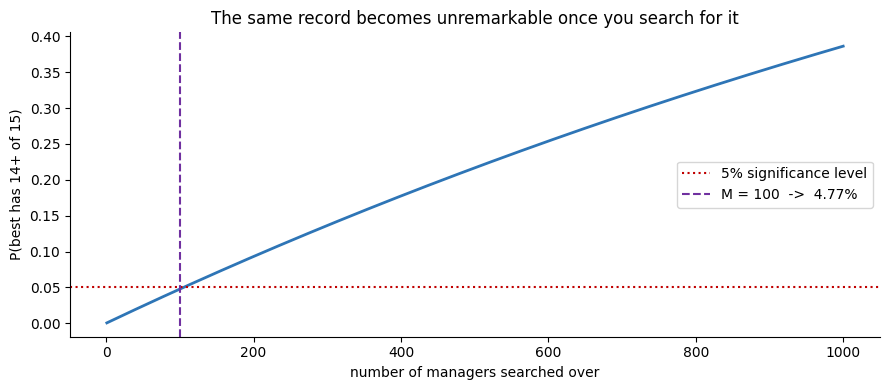

In [12]:
# how the "surprise" evaporates as the search widens
sizes = [1, 5, 10, 25, 50, 100, 250, 500, 1000]
table = pd.DataFrame({
    "managers M": sizes,
    "P(best >= 14)": [1 - (1 - q) ** m for m in sizes],
})
print(table.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

fig, ax = plt.subplots(figsize=(9, 4))
grid = np.arange(1, 1001)
ax.plot(grid, 1 - (1 - q) ** grid, color="#2E75B6", lw=2)
ax.axhline(0.05, color="#C00000", ls=":", lw=1.5, label="5% significance level")
ax.axvline(M, color="#7030A0", ls="--", lw=1.5, label=f"M = {M}  ->  {Q6:.2%}")
ax.set_xlabel("number of managers searched over")
ax.set_ylabel("P(best has 14+ of 15)")
ax.set_title("The same record becomes unremarkable once you search for it")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

### The lesson

A 14-of-15 record is a **1-in-2,048** event for a manager named in advance — overwhelming evidence
of skill, on the face of it. But search 100 managers for the best one and the probability of seeing
such a record by pure chance rises to **4.8%**, right at the edge of conventional significance. Search
a thousand and it is close to a coin flip.

This is the **multiple-comparisons problem**, and in finance it goes by names like data snooping,
backtest overfitting, or survivorship bias. It is the reason a fund's track record — or a trading
rule discovered by scanning thousands of candidates — carries far less information than its
standalone p-value suggests. The correct null hypothesis has to account for how many chances the
winner had to appear.

---
## 8. Question 7 — Monty Hall with four doors

> *4 doors: 2 goats, 2 prizes. You pick a door; Monty opens one of the other three revealing a goat;
> you may then switch to one of the two remaining unopened doors. Playing optimally, what is the
> probability of winning a prize?*

### Staying

Your first pick is made with no information, so

$$\mathbb P(\text{win}\mid\text{stay})=\frac{2}{4}=\tfrac12$$

### Switching

Condition on what is behind your door. After Monty opens a goat door, **two** doors remain unopened
besides yours.

| your door | probability | the 2 remaining doors hold | $\mathbb P(\text{win}\mid\text{switch})$ |
|---|---|---|---|
| a **prize** | $\tfrac12$ | 1 prize, 1 goat — Monty took the other goat | $\tfrac12$ |
| a **goat** | $\tfrac12$ | 2 prizes — Monty had to take the *only* other goat | $1$ |

$$\mathbb P(\text{win}\mid\text{switch})=\tfrac12\cdot\tfrac12+\tfrac12\cdot 1=\tfrac34$$

The engine of the puzzle is the second row. If your door hides a goat, there is exactly one goat left
among the other three doors, and Monty is **forced** to open it — handing you a guaranteed win. His
choice is not random; it is constrained by what he knows, and that constraint is the information you
are being given.

$$\boxed{\ \mathbb P(\text{win}\mid\text{optimal play})=\max\left(\tfrac12,\ \tfrac34\right)=0.75\ }$$

In [13]:
def monty_hall_exact(n_doors=4, n_prizes=2):
    """Exact probabilities of winning by staying and by switching."""
    n_goats = n_doors - n_prizes
    p_stay = n_prizes / n_doors

    # case A: first pick is a prize -> Monty opens a goat, leaving
    #         (n_prizes - 1) prizes and (n_goats - 1) goats unopened
    pA = n_prizes / n_doors
    winA = (n_prizes - 1) / (n_doors - 2)

    # case B: first pick is a goat -> Monty opens one of the remaining goats,
    #         leaving n_prizes prizes and (n_goats - 2) goats unopened
    pB = n_goats / n_doors
    winB = n_prizes / (n_doors - 2)

    return p_stay, pA * winA + pB * winB


p_stay, p_switch = monty_hall_exact(4, 2)
Q7 = max(p_stay, p_switch)

print(f"P(win | stay)              = {p_stay:.4f}")
print(f"P(win | switch)            = {p_switch:.4f}")
print(f"\nQ7  optimal play           = {Q7:.4f}   ->  submit {Q7:.2f}   (switch)")

P(win | stay)              = 0.5000
P(win | switch)            = 0.7500

Q7  optimal play           = 0.7500   ->  submit 0.75   (switch)


### Simulation

Analytical arguments about Monty Hall have a long history of being wrong, so let us just play the
game a million times.

In [14]:
def simulate_monty(n_trials=1_000_000, n_doors=4, n_prizes=2, seed=42):
    rng = np.random.default_rng(seed)
    wins_stay = wins_switch = 0

    for _ in range(n_trials):
        doors = np.zeros(n_doors, dtype=bool)
        doors[rng.choice(n_doors, n_prizes, replace=False)] = True   # True = prize
        pick = rng.integers(n_doors)

        # Monty opens a goat door that is not yours
        goats = [d for d in range(n_doors) if d != pick and not doors[d]]
        opened = goats[rng.integers(len(goats))]

        if doors[pick]:
            wins_stay += 1

        remaining = [d for d in range(n_doors) if d not in (pick, opened)]
        if doors[remaining[rng.integers(len(remaining))]]:
            wins_switch += 1

    return wins_stay / n_trials, wins_switch / n_trials


sim_stay, sim_switch = simulate_monty(1_000_000)

print(pd.DataFrame({
    "exact": [p_stay, p_switch],
    "simulated (1M games)": [sim_stay, sim_switch],
}, index=["stay", "switch"]).to_string(float_format=lambda v: f"{v:.4f}"))

assert abs(sim_switch - p_switch) < 0.005
print("\nsimulation confirms the analysis: switching wins 3 times in 4")

        exact  simulated (1M games)
stay   0.5000                0.4996
switch 0.7500                0.7506

simulation confirms the analysis: switching wins 3 times in 4


---
## 9. Answer summary

The same seven numbers appear on the `Answers` sheet of `assignment_2.xlsx`, computed there by live
formulas. If any cell of the workbook is edited, both should move together.

In [15]:
summary = pd.DataFrame([
    ("Q1", "Estimated return, efficient portfolio with 5% vol (%)", Q1,   f"{Q1:.2f}"),
    ("Q2", "True expected return of that same portfolio (%)",       Q2,   f"{Q2:.2f}"),
    ("Q3", "Value-at-Risk at 90%, monthly loss (%)",                VaR,  f"{VaR:.2f}"),
    ("Q4", "Conditional Value-at-Risk at 90%, monthly loss (%)",    CVaR, f"{CVaR:.2f}"),
    ("Q5", "P(12+ good years of 15 | no skill)",                    Q5,   f"{Q5:.4f}"),
    ("Q6", "P(best of 100 no-skill managers gets 14+ of 15)",       Q6,   f"{Q6:.4f}"),
    ("Q7", "P(win | 4-door Monty Hall, optimal play)",              Q7,   f"{Q7:.2f}"),
], columns=["Q", "question", "value", "submit"])

print(summary.to_string(index=False, float_format=lambda v: f"{v:.6f}"))

 Q                                              question    value submit
Q1 Estimated return, efficient portfolio with 5% vol (%) 5.318191   5.32
Q2       True expected return of that same portfolio (%) 3.855048   3.86
Q3                Value-at-Risk at 90%, monthly loss (%) 1.300577   1.30
Q4    Conditional Value-at-Risk at 90%, monthly loss (%) 2.161817   2.16
Q5                    P(12+ good years of 15 | no skill) 0.017578 0.0176
Q6       P(best of 100 no-skill managers gets 14+ of 15) 0.047667 0.0477
Q7              P(win | 4-door Monty Hall, optimal play) 0.750000   0.75


In [16]:
# ---- cross-check the notebook against the workbook ----------------------
# Requires the workbook to have been recalculated and saved by Excel or
# LibreOffice at least once, so that cached values are present.
try:
    import openpyxl
    wb = openpyxl.load_workbook(XLSX, data_only=True)
    sheet = wb["Answers"]
    excel_vals = [sheet.cell(r, 3).value for r in range(5, 12)]

    if all(v is None for v in excel_vals):
        print("Workbook has no cached values yet — open assignment_2.xlsx in Excel,\n"
              "let it recalculate, save, then re-run this cell.")
    else:
        check = summary.assign(excel=excel_vals)
        check["match"] = [
            (e is not None) and np.isclose(p, e, atol=1e-8)
            for p, e in zip(check["value"], check["excel"])
        ]
        print(check[["Q", "value", "excel", "match"]].to_string(
            index=False, float_format=lambda v: f"{v:.8f}"))
        print("\nall Excel and Python answers agree"
              if check["match"].all() else "\nMISMATCH - investigate")
except FileNotFoundError:
    print(f"{XLSX} not found next to this notebook.")

 Q      value      excel  match
Q1 5.31819147 5.31819147   True
Q2 3.85504792 3.85504792   True
Q3 1.30057667 1.30057667   True
Q4 2.16181667 2.16181667   True
Q5 0.01757812 0.01757813   True
Q6 0.04766656 0.04766656   True
Q7 0.75000000 0.75000000   True

all Excel and Python answers agree


---
## Notes for revision

**Q1–Q2 — mean-variance with a risk-free asset.** With cash available, every efficient portfolio is
$k\,\mathbf V^{-1}(\boldsymbol\mu-r_f\mathbf 1)$; the target volatility only fixes $k$. Solver and the
closed form must agree — if they do not, the usual culprit is the percent/decimal convention or the
"Make Unconstrained Variables Non-Negative" box being left ticked. The pair of questions together
makes the sharper point: an optimiser fed noisy means will lever into whichever asset the noise
flattered, and the promised return partly evaporates. Estimation error in $\boldsymbol\mu$ costs
about 1.5 points of return here; error in $\mathbf V$ costs almost nothing.

**Q3–Q4 — tail risk.** VaR is a quantile of the loss distribution; CVaR summarises what lies beyond it. Use the module's estimator exactly as given — sum the largest $N-K_p+1$ losses, divide by $(1-p)N$ — because the two counts differ by one and a plain `mean()` of the tail silently gives a different answer (1.95 instead of 2.16 here).
Estimating them historically means no distributional assumption, but also means the answer rests on
6 observations, so the standard error is large. CVaR is the more informative of the two — it sees the
shape of the tail, not just where it starts — and it is coherent, which VaR is not.

**Q5–Q6 — track records.** A binomial test is easy; specifying the null correctly is not. The record
in Q5 was picked in advance and is significant at 1.8%; the record in Q6 is *better* yet only reaches
4.8% because it was selected as the maximum of 100 tries. Whenever performance is chosen after the
fact, the number of candidates has to enter the calculation.

**Q7 — conditioning on constrained information.** Monty's choice is not random: he must open a goat
door he did not have to choose freely. When your door hides a goat he has no discretion at all, and
that forced move is what tilts the odds to 3/4. The general lesson is about conditioning correctly on
*how* information arrived, not just on what it says.